# 🧠 Modelos para procesamiento de texto (NLP) ✍️

---

## 📍¿Qué es un modelo Transformer?

Los **Transformers** son modelos de inteligencia artificial basados en el **[mecanismo de atención](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)**, diseñados para procesar secuencias de texto de manera eficiente y contextual.  
Son la base de muchos modelos modernos de NLP como BERT, GPT, T5, Mistral y LLaMA.


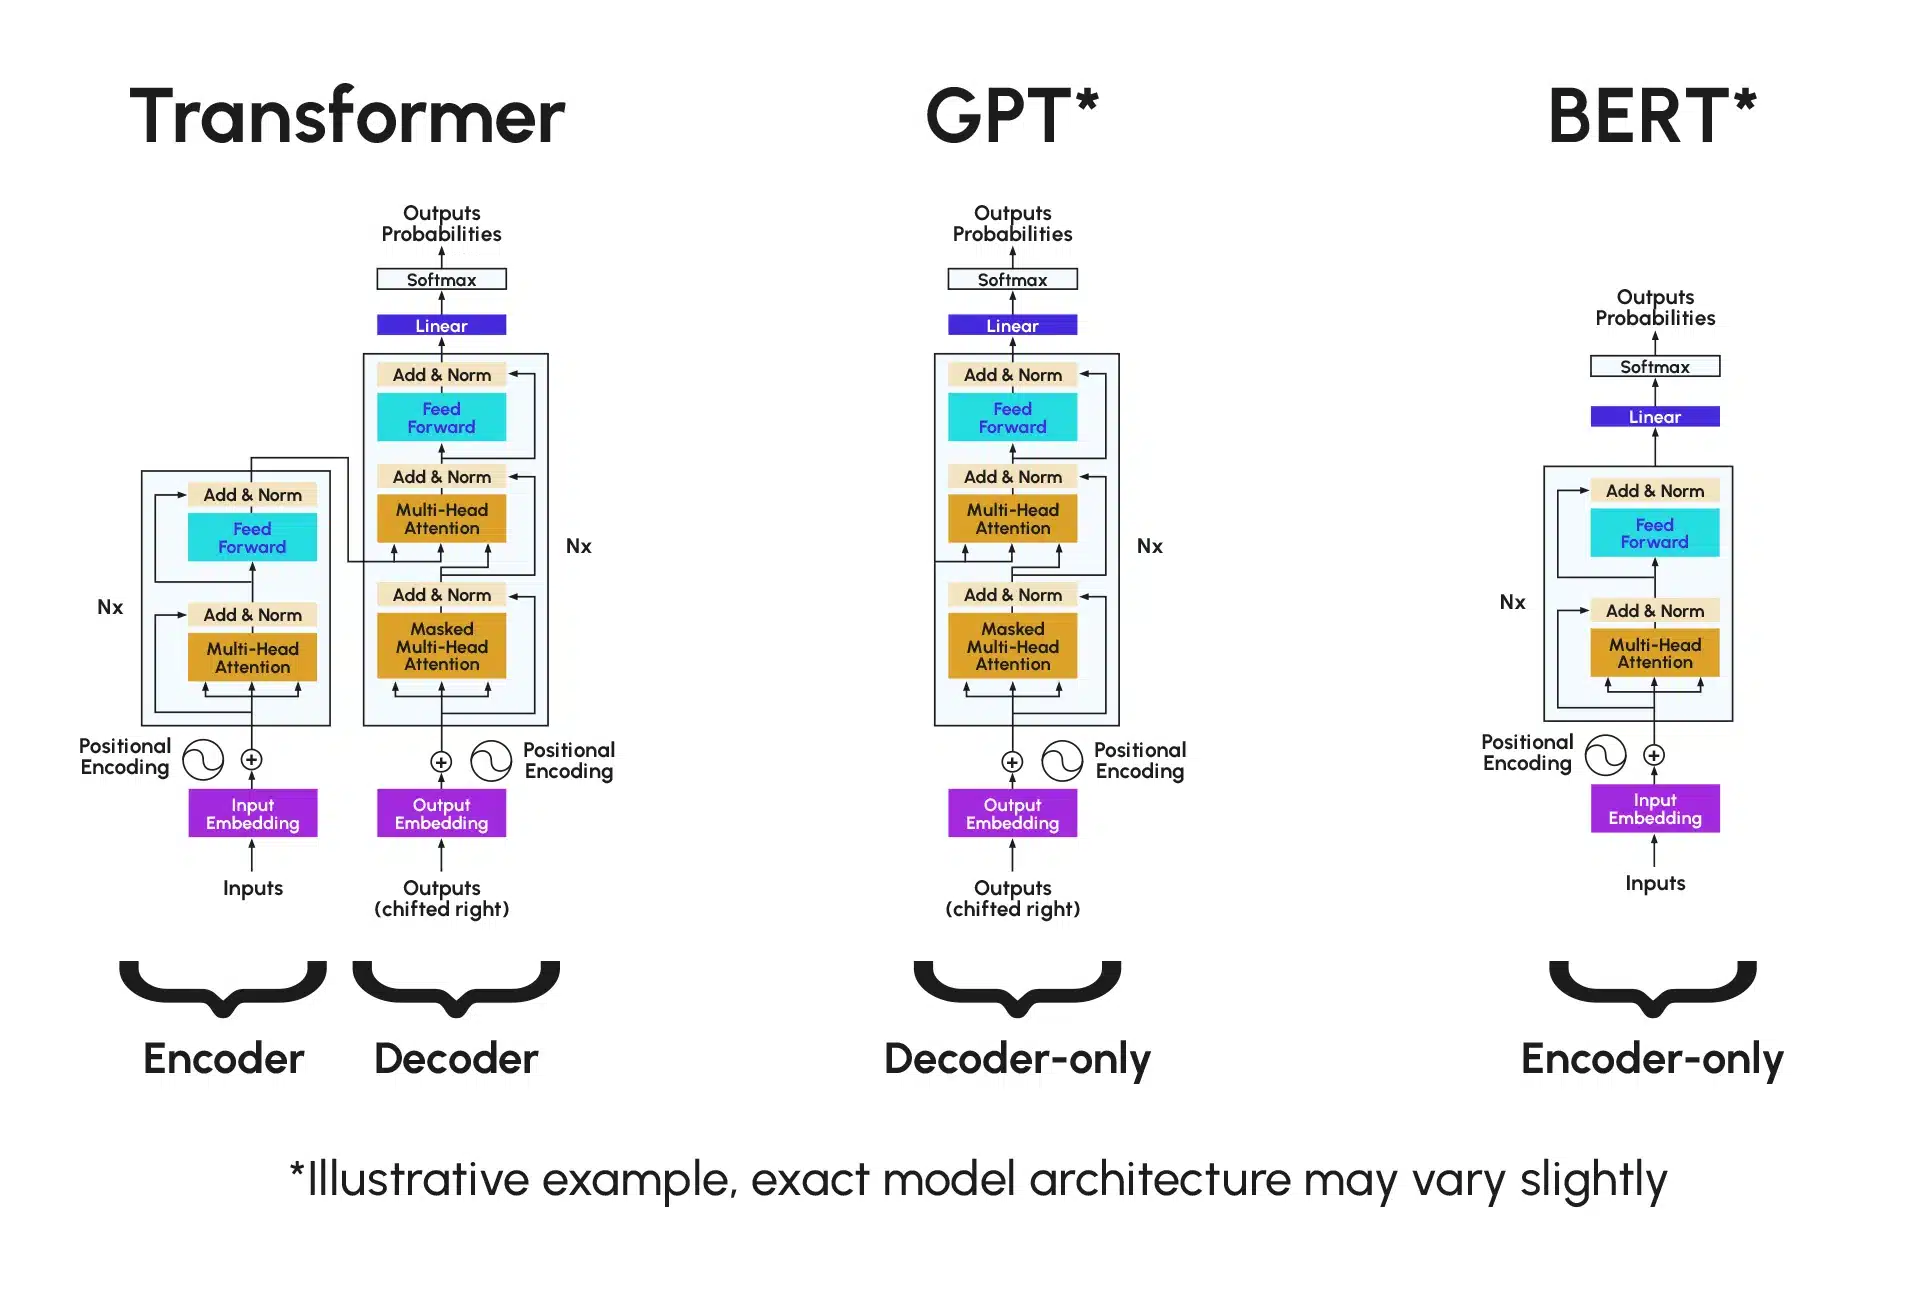

### ⚙️ Principales ventajas:
- 🧩 **Comprenden contexto de largo alcance**, analizando relaciones entre palabras incluso a gran distancia.  
- 🚀 **Escalan fácilmente** a millones o miles de millones de parámetros.  
- 🧠 **Soportan múltiples tareas**: clasificación, resumen, traducción, respuesta a preguntas, entre otras.  

---

## 📍Principales arquitecturas

Existen tres tipos principales de arquitecturas Transformer, cada una enfocada en distintos tipos de tareas:

| 🏗️ Tipo de arquitectura | 💡 Descripción | 📚 Ejemplo |
|--------------------------|----------------|-------------|
| **Encoder-only** | Se enfocan en comprender el texto de entrada. | 🧠 **BERT** → Ideal para clasificación o extracción de entidades (NER). |
| **Decoder-only** | Generan texto palabra por palabra a partir de un contexto previo. | ✍️ **GPT** → Perfecto para generación de texto o chatbots. |
| **Encoder-Decoder** | Traducen, resumen o transforman el texto de entrada en otro texto de salida. | 🔄 **T5, BART** → Usados para traducción o resumen automático. |

---

## 📍 Modelos más comunes

| 🧠 **Modelo** | 🏗️ **Arquitectura** | 🧩 **Tareas Principales** |
|:---------------|:--------------------|:--------------------------|
| **BERT** | Encoder | Clasificación, NER (Reconocimiento de entidades) |
| **GPT-2 / GPT-NeoX** | Decoder | Generación de texto libre |
| **T5** | Encoder-Decoder | Traducción, resumen de texto |
| **DistilBERT** | Encoder | Versión comprimida de BERT, más rápida |
| **Mistral / LLaMA2** | Decoder | LLM modernos para generación contextual |

# EJEMPLO DE USO DE T5

In [1]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = "cuda"

tokenizer = AutoTokenizer.from_pretrained("humarin/chatgpt_paraphraser_on_T5_base")

model = AutoModelForSeq2SeqLM.from_pretrained("humarin/chatgpt_paraphraser_on_T5_base").to(device)

config.json:   0%|          | 0.00/1.61k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [2]:
def paraphrase(
    question,
    num_beams=5,
    num_return_sequences=5,
    repetition_penalty=10.0,
    no_repeat_ngram_size=2,
    temperature=0.7,
    max_length=128
):
    input_ids = tokenizer(
        f'paraphrase: {question}',
        return_tensors="pt", padding="longest",
        max_length=max_length,
        truncation=True,
    ).input_ids.to(device)

    outputs = model.generate(
        input_ids, temperature=temperature, repetition_penalty=repetition_penalty,
        num_return_sequences=num_return_sequences, no_repeat_ngram_size=no_repeat_ngram_size,
        num_beams=num_beams,
        max_length=max_length
    )

    res = tokenizer.batch_decode(outputs, skip_special_tokens=True)

    return res

In [3]:
text = 'What are the best places to see in New York?'
paraphrase(text)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


['Which are the top destinations to explore in New York?',
 'What are some must-see places in New York?',
 'What are some of the must-see attractions in New York?',
 'What are some must-see attractions in New York?',
 'What are the top destinations to explore in New York?']

# ANALISIS DE SENTIMIENTOS CON BERT

In [4]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-classification", model="nlptown/bert-base-multilingual-uncased-sentiment")

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# PROBAMOS EL PIPELINE

In [5]:
texto = 'esta es la peor comida que puede existir en el mundo'
pipe(texto)

[{'label': '1 star', 'score': 0.9501059651374817}]

In [6]:
texto = 'esta es la mejor escuela del mundo'
pipe(texto)

[{'label': '5 stars', 'score': 0.8816702961921692}]

In [7]:
texto = 'me gusto la canción, pero podria ser mejor'
pipe(texto)

[{'label': '3 stars', 'score': 0.6975191831588745}]